# 3.2 Time Series Components

In [50]:
import polars as pl

us_employment = pl.read_csv(
    "../data/fpp3/us_employment.csv",
    null_values=["NA"],
    schema_overrides={"Employed": pl.Float64},
)

us_employment = us_employment.with_columns(
    pl.col("Month")
    .str.strptime(pl.Date, "%Y %b")
    .alias("Month")
)

In [51]:
us_retail_employment = (
    us_employment
    .filter(
        pl.col("Month").dt.year() >= 1990,
        pl.col("Title") == "Retail Trade"
    )
    .drop("Series_ID")
)
us_retail_employment

Month,Title,Employed
date,str,f64
1990-01-01,"""Retail Trade""",13255.8
1990-02-01,"""Retail Trade""",12966.3
1990-03-01,"""Retail Trade""",12938.2
1990-04-01,"""Retail Trade""",13012.3
1990-05-01,"""Retail Trade""",13108.3
…,…,…
2019-05-01,"""Retail Trade""",15691.6
2019-06-01,"""Retail Trade""",15775.5
2019-07-01,"""Retail Trade""",15785.9


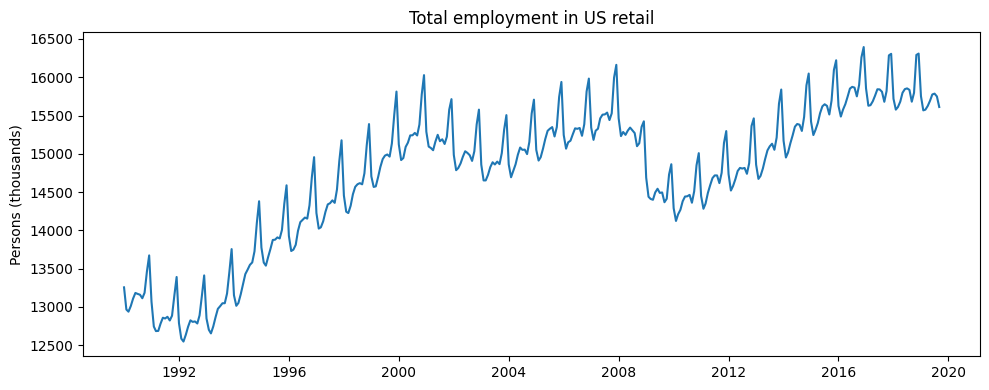

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(
    us_retail_employment["Month"],
    us_retail_employment["Employed"]
)

plt.ylabel("Persons (thousands)")
plt.title("Total employment in US retail")

plt.tight_layout()
plt.show()

### taking log of employed to check if the series is multiplicative

In [53]:
import numpy as np
us_retail_employment = us_retail_employment.with_columns(
    pl.col("Employed").log().alias("log_employed")
)

us_retail_employment

Month,Title,Employed,log_employed
date,str,f64,f64
1990-01-01,"""Retail Trade""",13255.8,9.49219
1990-02-01,"""Retail Trade""",12966.3,9.470109
1990-03-01,"""Retail Trade""",12938.2,9.467939
1990-04-01,"""Retail Trade""",13012.3,9.47365
1990-05-01,"""Retail Trade""",13108.3,9.481001
…,…,…,…
2019-05-01,"""Retail Trade""",15691.6,9.660881
2019-06-01,"""Retail Trade""",15775.5,9.666213
2019-07-01,"""Retail Trade""",15785.9,9.666872


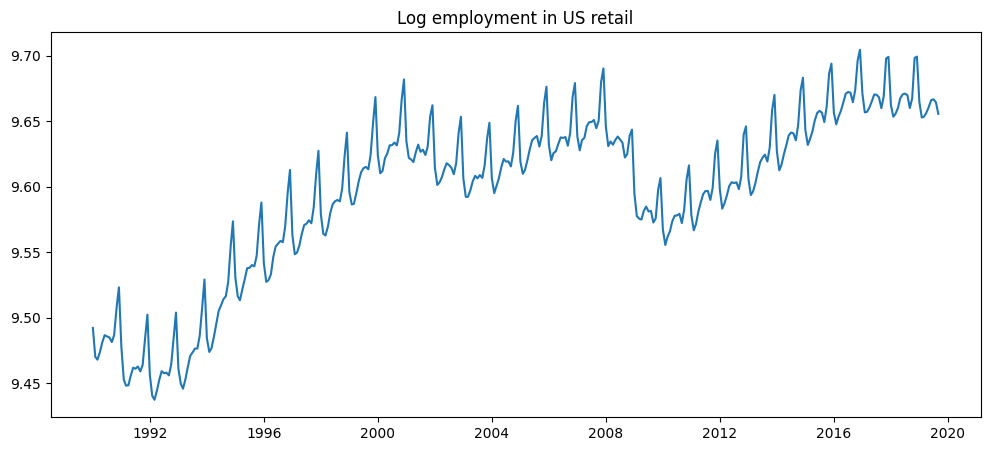

In [54]:
pdf = us_retail_employment.to_pandas()

plt.figure(figsize=(12, 5))
plt.plot(pdf["Month"], pdf["log_employed"])
plt.title("Log employment in US retail")
plt.show()

In [55]:
from statsmodels.tsa.seasonal import STL

stl = STL(
    us_retail_employment["Employed"],
    period=12  # monthly data
)

result = stl.fit()

In [56]:
import pandas as pd
stl = STL(
    us_retail_employment["Employed"],
    period=12
)

result = stl.fit()

dcmp = pd.DataFrame({
    "Month": us_retail_employment["Month"],
    "Employed": us_retail_employment["Employed"],
    "trend": result.trend,
    "season_year": result.seasonal,
    "remainder": result.resid,
})

dcmp["season_adjust"] = (
    dcmp["Employed"] - dcmp["season_year"]
)

dcmp

,Month,Employed,trend,season_year,remainder,season_adjust
0,1990-01-01,13255.8,13296.248875,-3.699986,-36.748889,13259.499986
1,1990-02-01,12966.3,13276.085176,-288.398325,-21.386851,13254.698325
2,1990-03-01,12938.2,13255.662673,-306.657625,-10.805048,13244.857625
3,1990-04-01,13012.3,13234.986479,-235.775229,13.088750,13248.075229
4,1990-05-01,13108.3,13214.070964,-115.398800,9.627836,13223.698800
...,...,...,...,...,...,...
352,2019-05-01,15691.6,15784.875120,-76.457708,-16.817412,15768.057708
353,2019-06-01,15775.5,15778.842886,-1.628297,-1.714589,15777.128297
354,2019-07-01,15785.9,15772.740656,11.713653,1.445691,15774.186347
355,2019-08-01,15749.5,15766.582336,-12.524782,-4.557554,15762.024782


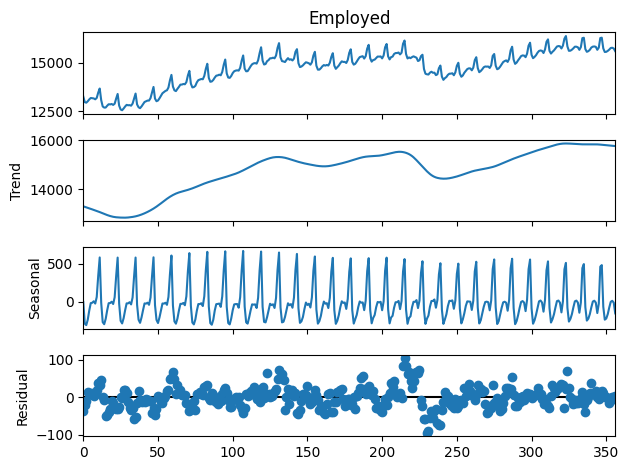

In [57]:
result.plot()
plt.show()

# 3.3 Moving Averages

In [58]:
us_retail_employment = us_retail_employment.with_columns(
    pl.col("Employed")
    .rolling_mean(window_size=12)
    .rolling_mean(window_size=2)
    .alias("cma_12")
)

us_retail_employment

Month,Title,Employed,log_employed,cma_12
date,str,f64,f64,f64
1990-01-01,"""Retail Trade""",13255.8,9.49219,null
1990-02-01,"""Retail Trade""",12966.3,9.470109,null
1990-03-01,"""Retail Trade""",12938.2,9.467939,null
1990-04-01,"""Retail Trade""",13012.3,9.47365,null
1990-05-01,"""Retail Trade""",13108.3,9.481001,null
…,…,…,…,…
2019-05-01,"""Retail Trade""",15691.6,9.660881,15823.225
2019-06-01,"""Retail Trade""",15775.5,9.666213,15815.933333
2019-07-01,"""Retail Trade""",15785.9,9.666872,15810.183333


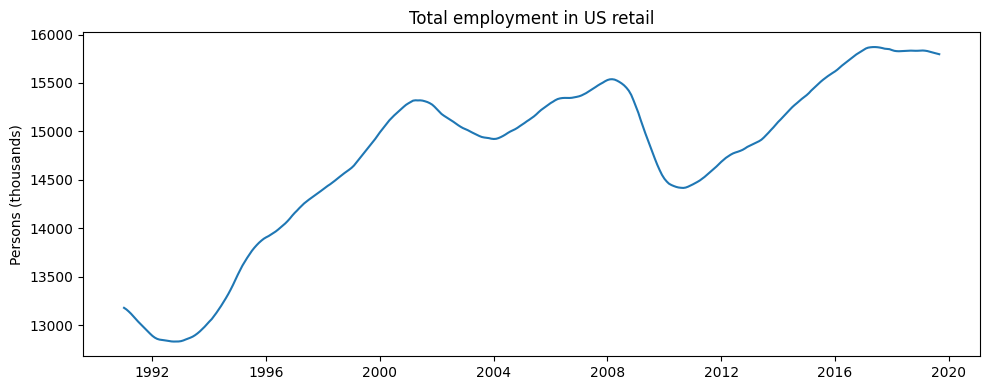

In [59]:
plt.figure(figsize=(10, 4))

plt.plot(
    us_retail_employment["Month"],
    us_retail_employment["cma_12"]
)

plt.ylabel("Persons (thousands)")
plt.title("Total employment in US retail")

plt.tight_layout()
plt.show()